# Miniature dataset generation (simple simulator)
This notebook demonstrates how to generate a small miniature dataset using the
`SimpleSimulator`. The miniature configuration compresses the spectral axis to
128 channels and ensures the total spectrogram length is ≤ 128 pixels.

In [48]:
# Cell 2: imports and generation
from pathlib import Path
import numpy as np
import spectangle 
from spectangle.simulations.simple import SimpleSimulator
from spectangle.simulations.io import save_simulation, load_simulation

output = Path("data/raw/simple_mini_100s.h5")
output.parent.mkdir(parents=True, exist_ok=True)

sim = SimpleSimulator(n_sources=1, image_shape=(12,32), n_spectral_pixels=32, seed=42)
print("Spectrogram shape:", sim.spectrogram_shape)

# # Generate dataset if missing
# if not output.exists():
#     samples = []
#     for i in range(100):
#         samples.append(sim.generate_one(np.random.default_rng(i)))
#     save_simulation(samples, output, metadata={"note":"miniature simple dataset"})
#     print("Wrote:", output)
# else:
#     print("Dataset already exists:", output)

samples = []
for i in range(100):
    samples.append(sim.generate_one(np.random.default_rng(i)))
save_simulation(samples, output, metadata={"note":"miniature simple dataset"})
print("Wrote:", output)

Spectrogram shape: (18, 96)
Wrote: data/raw/simple_mini_100s.h5
Wrote: data/raw/simple_mini_100s.h5


## Inspect and visualise generated samples
Load the HDF5 produced above and inspect metadata, shapes, and visualise an
example spectrogram and spectral slices. This helps ensure the simulator
produced consistent data structures for training.

Top-level keys: ['metadata', 'wavelengths', 'samples']

Metadata:
  note: miniature simple dataset

Sample 0 keys: ['cube', 'direct_image', 'source_temps', 'source_xs', 'source_ys', 'spectrograms']
cube shape: (32, 12, 32)
spectrograms shape: (4, 18, 96)


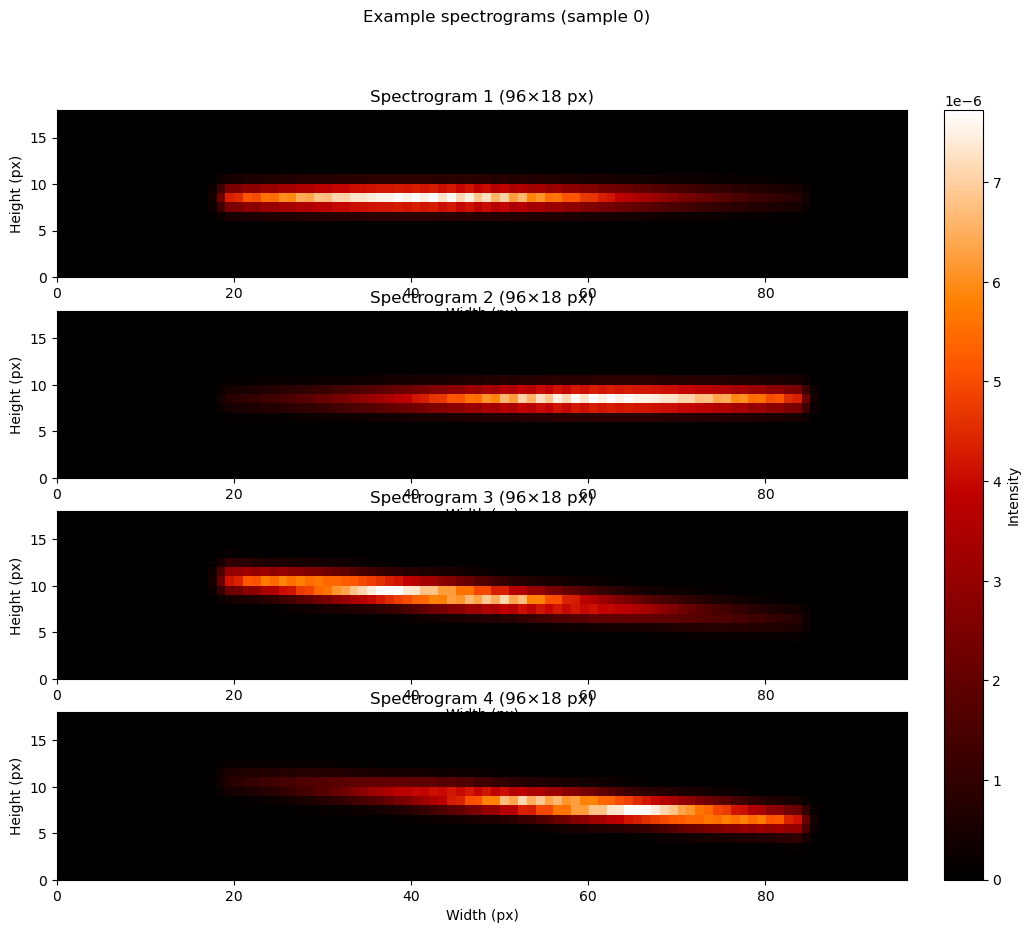

In [45]:
from spectangle.simulations.io import load_simulation
import matplotlib.pyplot as plt

data = load_simulation(output)
print('Top-level keys:', list(data.keys()))
print('\nMetadata:')
for k, v in data['metadata'].items():
    print(f'  {k}:', v)

s0 = data['samples'][0]
print('\nSample 0 keys:', list(s0.keys()))
print('cube shape:', s0['cube'].shape)
print('spectrograms shape:', s0['spectrograms'].shape)

wavelengths = data['wavelengths']
cube0 = s0['cube']
specs0 = s0['spectrograms']
direct0 = s0.get('direct_image')

fig, axs = plt.subplots(4, 1, figsize=(12, 10))  # 4 rows, 1 column

# Collect all images so we can attach a single colorbar later
ims = []

for k in range(4):
    ax = axs[k]
    h, w = specs0[k].shape  # height and width of the spectrogram

    # Show image with extent so axes reflect image size
    im = ax.imshow(specs0[k], origin='lower', cmap='gist_heat',
                   extent=[0, w, 0, h], aspect='auto')
    ims.append(im)

    ax.set_title(f"Spectrogram {k+1} ({w}×{h} px)")
    ax.set_xlabel("Width (px)")
    ax.set_ylabel("Height (px)")

# Create ONE shared colorbar
cbar = fig.colorbar(ims[0], ax=axs, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label("Intensity")
plt.suptitle("Example spectrograms (sample 0)")
# plt.tight_layout()
plt.show()

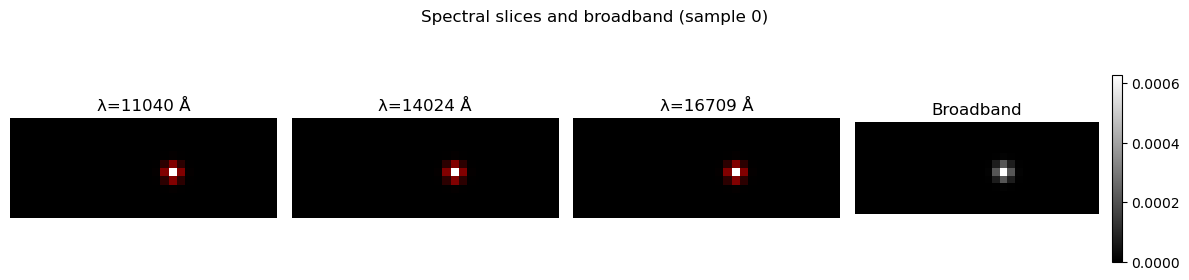

In [47]:
# Spectral slices
n_lambda = cube0.shape[0]
idxs = [int(n_lambda*0.2), int(n_lambda*0.5), int(n_lambda*0.8)]
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
for i, idx in enumerate(idxs):
    axs[i].imshow(cube0[idx], origin='lower', cmap='gist_heat')
    axs[i].set_title(f'λ={int(wavelengths[idx])} Å')
    axs[i].axis('off')
broad = cube0.sum(axis=0)
im = axs[3].imshow(broad, origin='lower', cmap='gray')
axs[3].set_title('Broadband')
axs[3].axis('off')
fig.colorbar(im, ax=axs[3], fraction=0.035)
plt.suptitle('Spectral slices and broadband (sample 0)')
plt.tight_layout()
plt.show()

Top-level keys: ['metadata', 'wavelengths', 'samples']

Metadata:
  note: miniature simple dataset

Sample 0 keys: ['cube', 'direct_image', 'source_temps', 'source_xs', 'source_ys', 'spectrograms']
cube shape: (32, 16, 32)
spectrograms shape: (4, 22, 96)


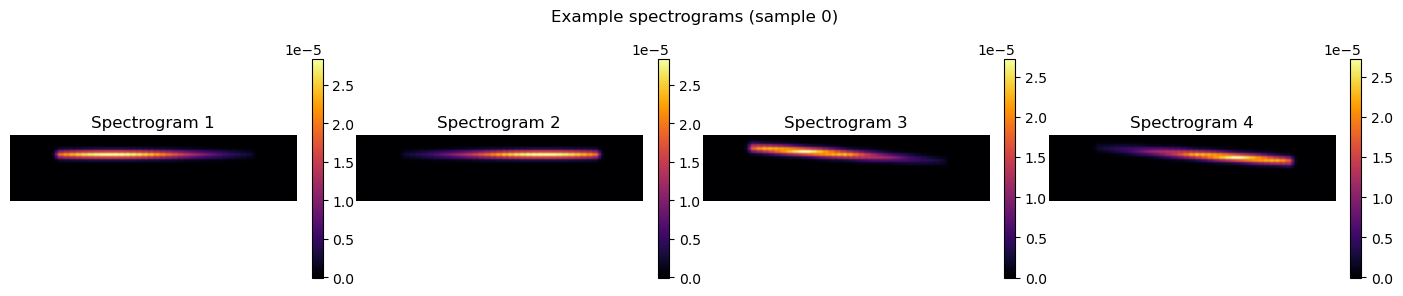

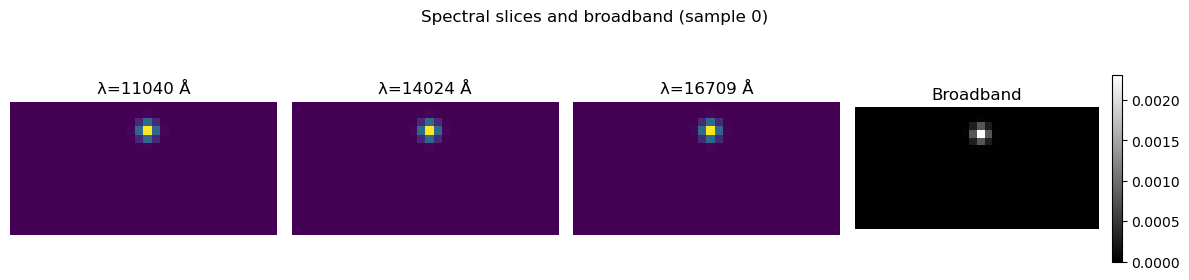

In [34]:
from spectangle.simulations.io import load_simulation
import matplotlib.pyplot as plt

data = load_simulation(output)
print('Top-level keys:', list(data.keys()))
print('\nMetadata:')
for k, v in data['metadata'].items():
    print(f'  {k}:', v)

s0 = data['samples'][1]
print('\nSample 0 keys:', list(s0.keys()))
print('cube shape:', s0['cube'].shape)
print('spectrograms shape:', s0['spectrograms'].shape)

wavelengths = data['wavelengths']
cube0 = s0['cube']
specs0 = s0['spectrograms']
direct0 = s0.get('direct_image')

# Show the 4 spectrograms
fig, axs = plt.subplots(1, 4, figsize=(14, 3))
for k in range(4):
    ax = axs[k]
    im = ax.imshow(specs0[k], origin='lower', cmap='inferno')
    ax.set_title(f'Spectrogram {k+1}')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.035)
plt.suptitle('Example spectrograms (sample 0)')
plt.tight_layout()
plt.show()

# Spectral slices
n_lambda = cube0.shape[0]
idxs = [int(n_lambda*0.2), int(n_lambda*0.5), int(n_lambda*0.8)]
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
for i, idx in enumerate(idxs):
    axs[i].imshow(cube0[idx], origin='lower', cmap='viridis')
    axs[i].set_title(f'λ={int(wavelengths[idx])} Å')
    axs[i].axis('off')
broad = cube0.sum(axis=0)
im = axs[3].imshow(broad, origin='lower', cmap='gray')
axs[3].set_title('Broadband')
axs[3].axis('off')
fig.colorbar(im, ax=axs[3], fraction=0.035)
plt.suptitle('Spectral slices and broadband (sample 0)')
plt.tight_layout()
plt.show()

In [35]:
specs0.shape , cube0.shape , direct0.shape

((4, 22, 96), (32, 16, 32), (22, 96))

In [36]:
s0.keys()

dict_keys(['cube', 'direct_image', 'source_temps', 'source_xs', 'source_ys', 'spectrograms'])

In [37]:
s0["source_xs"]

array([16.283718], dtype=float32)

## Quick checks and suggestions
- Verify `pad_x` and `pad_y` in metadata match expected dispersion padding.
- Run a small training experiment (see training notebooks) to validate the
  dataset end-to-end.

If you want, I can: add a dedicated PyTorch Dataset class under
`spectangle/data_loaders/` and unit tests to validate saved HDF5 shapes.